# **실습05 : 종합실습**
* CIFAR-10 데이터 세트
    * AlexNet의 창시자 Alex krizhevsky가 수집하여 만든 데이터 셋
    * 10개 클래스에 32x32 컬러 이미지 60000개로 구성되어 있으며, 클래스당 6000개 이미지가 있습니다. 50000개의 훈련 이미지와 10000개의 테스트 이미지가 있다.
* 모델 평가 : accuracy score
    * 지금까지 배운 내용을 총 동원해서 accuracy를 높여 보자.

![](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)


## 1.환경준비

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 학습을 위한 함수

In [3]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [4]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [6]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [7]:
train_dataset = datasets.CIFAR10(root="./", train=True, download=True, transform=ToTensor())
test_dataset = datasets.CIFAR10(root="./", train=False, download=True, transform=ToTensor())

100%|██████████| 170M/170M [00:05<00:00, 29.7MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [8]:
train_dataset, test_dataset

(Dataset CIFAR10
     Number of datapoints: 50000
     Root location: ./
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset CIFAR10
     Number of datapoints: 10000
     Root location: ./
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

* dataset.data : 구조가 이전과 다르다.
    * 파이토치가 받아들이는 구조 : (50000, 3, 32, 32)
    * 제공되는 구조 : (50000, 32, 32, 3)
        * data loader를 이용하면 자동으로 변환해줌 : (n, 3, 32, 32)

In [9]:
train_dataset.data.shape

(50000, 32, 32, 3)

* train_dataset.targets : 리스트

In [10]:
 train_dataset.targets[:10]

[6, 9, 9, 4, 1, 1, 2, 7, 8, 3]

* y(target)의 클래스

In [11]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

* 데이터 1건

In [12]:
train_dataset[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

* 데이터 이미지 확인

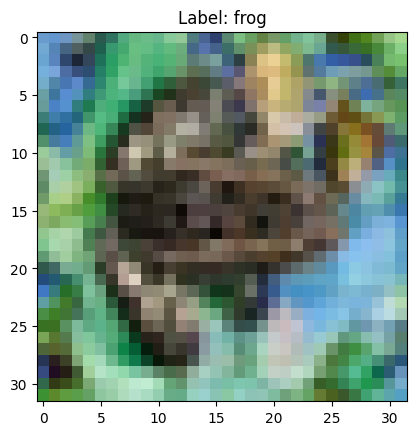

In [13]:
n = 200
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image)
plt.title(f"Label: {train_dataset.classes[label]}")
plt.show()

## 2.데이터 준비

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [14]:
# 배치 사이즈를 지정해서 Data Loader로 선언하기
batch_size = 64
train_dataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# 첫번째 배치만 로딩해서 살펴보기
for temp_X, temp_y in train_dataLoader:
    print(f"Shape of X [N, C, H, W]: {temp_X.shape}")
    print(f"Shape of y: {temp_y.shape} {temp_y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64


데이터 로더를 통과한 데이터의 결과를 보면 [64, 3, 32, 32]

### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나온다.
    * 스케일링 안된 데이터
    * **5000, 28, 28, 3** : 채널 차원이 뒤에 나옴.
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 차원 위치 변환 : **5000, 3, 28, 28**

In [16]:
# 1) 데이터와 레이블 추출
test_data = test_dataset.data  # x : (10000, 32, 32, 3)
test_targets = np.array(test_dataset.targets) # y

# 2) 데이터 위치 조정 : [n(0), 세로픽셀(1), 가로픽셀(2), 채널(3)] -> [n(0), 채널(3), 세로픽셀(1), 가로픽셀(2)]
test_data = test_data.transpose((0, 3, 1, 2))  # (10000, 3, 32, 32)

# 3) 텐서로 변환
test_data = torch.tensor(test_data, dtype=torch.float32)
test_targets = torch.tensor(test_targets, dtype=torch.int64)

# 변환된 데이터의 형태 확인
test_data.shape, test_targets.shape

(torch.Size([10000, 3, 32, 32]), torch.Size([10000]))

In [17]:
# 4) 텐서 데이터셋을 validation 5000건, test 5000건으로 나누기
x_val, x_test = test_data[:5000], test_data[5000:]
y_val, y_test = test_targets[:5000], test_targets[5000:]

In [18]:
# x_val, y_val, x_test, y_test의 shape 확인
x_val.shape, y_val.shape, x_test.shape, y_test.shape

(torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]),
 torch.Size([5000, 3, 32, 32]),
 torch.Size([5000]))

* 스케일링

In [19]:
x_val = x_val / 255.0
x_test = x_test / 255.0

## 3.모델링1 : MNIST와 동일한 구조로 모델링

### (1) 모델 선언

* nn.Sequential

In [20]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
           Flatten-7                 [-1, 4096]               0
            Linear-8                  [-1, 128]         524,416
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 545,098
Trainable params: 545,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 2.08
Estimated T

* Class

In [21]:
class CustomCNN1(nn.Module):
    def __init__(self, n_class):
        super(CustomCNN1, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, n_class)
        self.flat = nn.Flatten()
        self.relu = nn.ReLU()

    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flat(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [22]:
n_class = 10
model = CustomCNN1(n_class).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
              ReLU-5           [-1, 64, 16, 16]               0
         MaxPool2d-6             [-1, 64, 8, 8]               0
           Flatten-7                 [-1, 4096]               0
            Linear-8                  [-1, 128]         524,416
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 545,098
Trainable params: 545,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.88
Params size (MB): 2.08
Estimated T

### (2) 학습

Epoch 1, train loss : 1.4792, val loss : 1.2254, val acc : 0.5606
Epoch 2, train loss : 1.1186, val loss : 1.0282, val acc : 0.6472
Epoch 3, train loss : 0.9592, val loss : 0.9703, val acc : 0.6714
Epoch 4, train loss : 0.8687, val loss : 0.9229, val acc : 0.6816
Epoch 5, train loss : 0.7928, val loss : 0.9254, val acc : 0.6810
Epoch 6, train loss : 0.7292, val loss : 0.8619, val acc : 0.7148
Epoch 7, train loss : 0.6730, val loss : 0.8364, val acc : 0.7182
Epoch 8, train loss : 0.6110, val loss : 0.8546, val acc : 0.7216
Epoch 9, train loss : 0.5604, val loss : 0.8871, val acc : 0.7156
Epoch 10, train loss : 0.5074, val loss : 0.8873, val acc : 0.7178
Epoch 11, train loss : 0.4583, val loss : 0.9403, val acc : 0.7172
Epoch 12, train loss : 0.4106, val loss : 0.9523, val acc : 0.7158
Epoch 13, train loss : 0.3659, val loss : 0.9930, val acc : 0.7210
Epoch 14, train loss : 0.3206, val loss : 1.0483, val acc : 0.7140
Epoch 15, train loss : 0.2870, val loss : 1.0803, val acc : 0.7152
Epoc

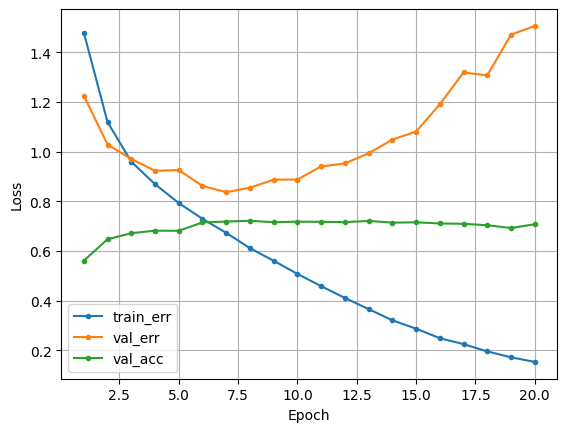

In [23]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

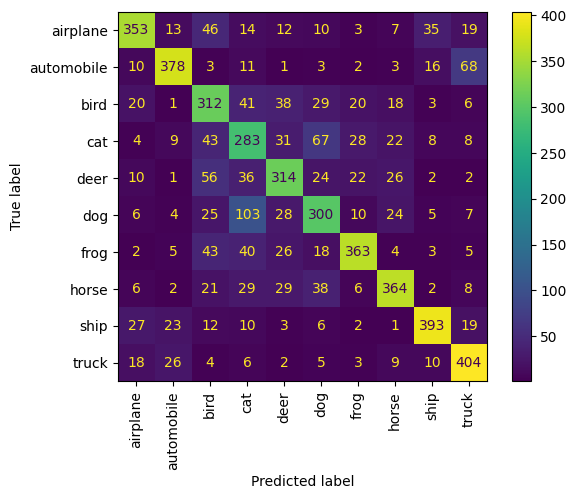

Accuracy : 0.6928
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.77      0.69      0.73       512
  automobile       0.82      0.76      0.79       495
        bird       0.55      0.64      0.59       488
         cat       0.49      0.56      0.53       503
        deer       0.65      0.64      0.64       493
         dog       0.60      0.59      0.59       512
        frog       0.79      0.71      0.75       509
       horse       0.76      0.72      0.74       505
        ship       0.82      0.79      0.81       496
       truck       0.74      0.83      0.78       487

    accuracy                           0.69      5000
   macro avg       0.70      0.69      0.70      5000
weighted avg       0.70      0.69      0.70      5000



In [24]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## 4.모델링2 : 보다 복잡한 모델링

### (1) 모델 선언

* nn.Sequential

In [25]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
          Flatten-10                 [-1, 4096]               0
           Linear-11                  [-1, 512]       2,097,664
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
             ReLU-14                  [

* Class

In [26]:
class CustomCNN2(nn.Module):
    def __init__(self, n_class):
        super(CustomCNN2, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc4 = nn.Linear(64, n_class)
        self.flat = nn.Flatten()
        self.relu = nn.ReLU()

    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flat(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [27]:
n_class = 10
model = CustomCNN2(n_class).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
          Flatten-10                 [-1, 4096]               0
           Linear-11                  [-1, 512]       2,097,664
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
             ReLU-14                  [

### (2) 학습

Epoch 1, train loss : 1.6401, val loss : 1.3753, val acc : 0.5170
Epoch 2, train loss : 1.1889, val loss : 1.0642, val acc : 0.6228
Epoch 3, train loss : 0.9820, val loss : 0.9289, val acc : 0.6724
Epoch 4, train loss : 0.8240, val loss : 0.8916, val acc : 0.6904
Epoch 5, train loss : 0.7129, val loss : 0.8433, val acc : 0.7120
Epoch 6, train loss : 0.6219, val loss : 0.8645, val acc : 0.7108
Epoch 7, train loss : 0.5313, val loss : 0.8145, val acc : 0.7332
Epoch 8, train loss : 0.4600, val loss : 0.8246, val acc : 0.7444
Epoch 9, train loss : 0.3832, val loss : 0.9236, val acc : 0.7322
Epoch 10, train loss : 0.3231, val loss : 0.9752, val acc : 0.7312
Epoch 11, train loss : 0.2686, val loss : 1.0846, val acc : 0.7280
Epoch 12, train loss : 0.2302, val loss : 1.0512, val acc : 0.7388
Epoch 13, train loss : 0.1944, val loss : 1.1611, val acc : 0.7284
Epoch 14, train loss : 0.1653, val loss : 1.2266, val acc : 0.7270
Epoch 15, train loss : 0.1514, val loss : 1.3868, val acc : 0.7278
Epoc

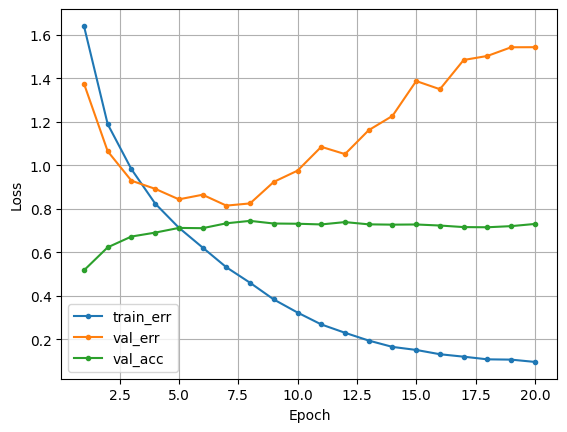

In [28]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

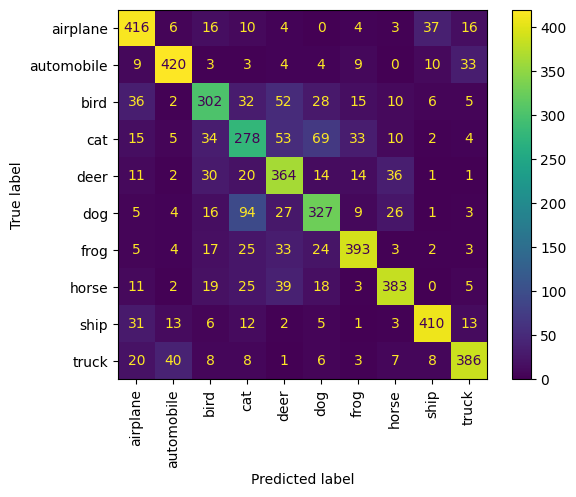

Accuracy : 0.7358
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.74      0.81      0.78       512
  automobile       0.84      0.85      0.85       495
        bird       0.67      0.62      0.64       488
         cat       0.55      0.55      0.55       503
        deer       0.63      0.74      0.68       493
         dog       0.66      0.64      0.65       512
        frog       0.81      0.77      0.79       509
       horse       0.80      0.76      0.78       505
        ship       0.86      0.83      0.84       496
       truck       0.82      0.79      0.81       487

    accuracy                           0.74      5000
   macro avg       0.74      0.74      0.74      5000
weighted avg       0.74      0.74      0.74      5000



In [29]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## 5.모델링3 : dropout 추가

### (1) 모델 선언

* nn.Sequential

In [30]:
n_class = 10
dropout_rate = 0.3

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(dropout_rate),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(dropout_rate),
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout(dropout_rate),
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(dropout_rate),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
           Dropout-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
              ReLU-6          [-1, 128, 16, 16]               0
         MaxPool2d-7            [-1, 128, 8, 8]               0
           Dropout-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
          Dropout-12            [-1, 256, 4, 4]               0
          Flatten-13                 [-1, 4096]               0
           Linear-14                  [

* Class

In [31]:
class CustomCNN3(nn.Module):
    def __init__(self, n_class, dropout_rate):
        super(CustomCNN3, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc4 = nn.Linear(64, n_class)
        self.flat = nn.Flatten()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = self.flat(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc4(x)
        return x

In [32]:
n_class = 10
dropout_rate = 0.3

model = CustomCNN3(n_class, dropout_rate).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
           Dropout-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
              ReLU-6          [-1, 128, 16, 16]               0
         MaxPool2d-7            [-1, 128, 8, 8]               0
           Dropout-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
             ReLU-10            [-1, 256, 8, 8]               0
        MaxPool2d-11            [-1, 256, 4, 4]               0
          Dropout-12            [-1, 256, 4, 4]               0
          Flatten-13                 [-1, 4096]               0
           Linear-14                  [

### (2) 학습

Epoch 1, train loss : 1.7489, val loss : 1.3241, val acc : 0.5194
Epoch 2, train loss : 1.3513, val loss : 1.1161, val acc : 0.6030
Epoch 3, train loss : 1.1983, val loss : 1.0153, val acc : 0.6446
Epoch 4, train loss : 1.0905, val loss : 0.9597, val acc : 0.6650
Epoch 5, train loss : 1.0101, val loss : 0.8897, val acc : 0.6864
Epoch 6, train loss : 0.9621, val loss : 0.8500, val acc : 0.7032
Epoch 7, train loss : 0.9135, val loss : 0.7936, val acc : 0.7288
Epoch 8, train loss : 0.8751, val loss : 0.8111, val acc : 0.7228
Epoch 9, train loss : 0.8480, val loss : 0.7533, val acc : 0.7394
Epoch 10, train loss : 0.8217, val loss : 0.7423, val acc : 0.7480
Epoch 11, train loss : 0.7913, val loss : 0.7413, val acc : 0.7456
Epoch 12, train loss : 0.7786, val loss : 0.7384, val acc : 0.7456
Epoch 13, train loss : 0.7542, val loss : 0.7108, val acc : 0.7556
Epoch 14, train loss : 0.7329, val loss : 0.7226, val acc : 0.7518
Epoch 15, train loss : 0.7209, val loss : 0.7005, val acc : 0.7596
Epoc

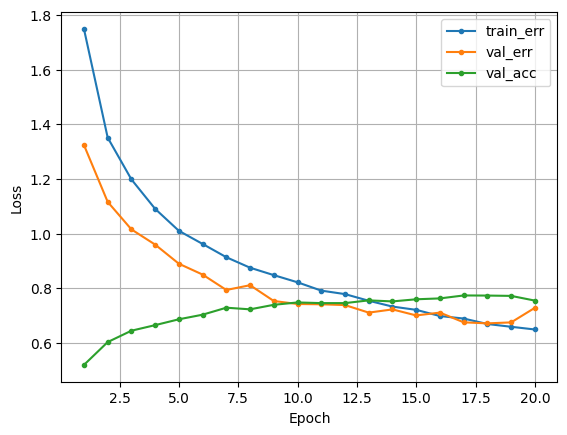

In [33]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataLoader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

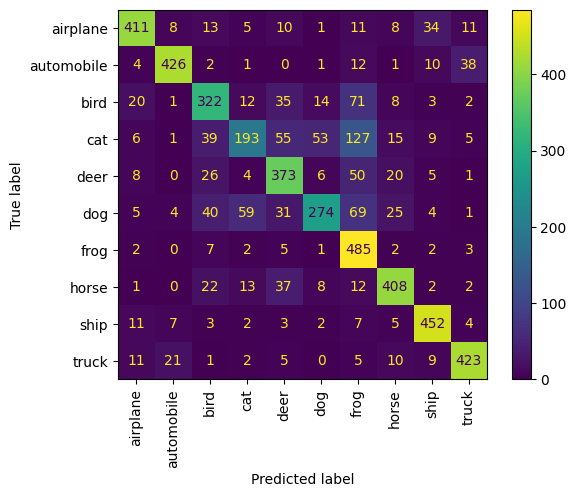

Accuracy : 0.7534
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    airplane       0.86      0.80      0.83       512
  automobile       0.91      0.86      0.88       495
        bird       0.68      0.66      0.67       488
         cat       0.66      0.38      0.48       503
        deer       0.67      0.76      0.71       493
         dog       0.76      0.54      0.63       512
        frog       0.57      0.95      0.71       509
       horse       0.81      0.81      0.81       505
        ship       0.85      0.91      0.88       496
       truck       0.86      0.87      0.87       487

    accuracy                           0.75      5000
   macro avg       0.76      0.75      0.75      5000
weighted avg       0.76      0.75      0.75      5000



In [34]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))